In [ ]:
#Max Keller
#Some of this assignment was done with the assistance of ChatGPT GPT-5.2
print('test kernel')

test kernel


Reading: C:\Users\mkeller\Downloads\tl_2025_us_state\tl_2025_us_state.shp
Rows: 56, CRS: EPSG:4269


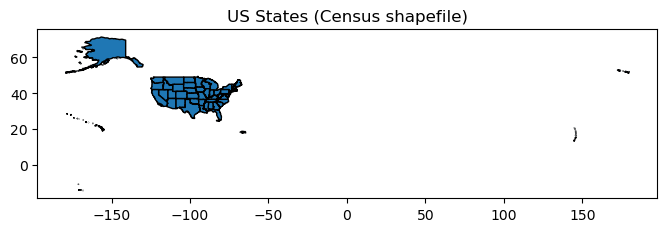

In [8]:
# Cell 2: Load and display the Census states shapefile
import geopandas as gpd
from pathlib import Path
import matplotlib.pyplot as plt

states_dir = Path(r"C:\Users\mkeller\Downloads\tl_2025_us_state")
states_shp = next(states_dir.glob("*.shp"))
print("Reading:", states_shp)
states = gpd.read_file(states_shp)
print(f"Rows: {len(states)}, CRS: {states.crs}")

# show table head
states.head()

# quick plot
ax = states.plot(figsize=(8, 6), edgecolor='black')
ax.set_title('US States (Census shapefile)')
plt.show()


Reading populated places: C:\Users\mkeller\Downloads\ne_10m_populated_places\ne_10m_populated_places.shp
Reading states (again) for robustness: C:\Users\mkeller\Downloads\tl_2025_us_state\tl_2025_us_state.shp
States CRS: EPSG:4269 Places CRS: EPSG:4326
Reprojecting places to states CRS...
Found 11 populated places in Alabama


,SCALERANK,NATSCALE,LABELRANK,FEATURECLA,NAME,NAMEPAR,NAMEALT,NAMEASCII,ADM0CAP,CAPIN,...,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,FCLASS_TLC,geometry
692,8,10,1.0,Populated place,Auburn,NaN,NaN,Auburn,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-85.48084 32.6097)
693,8,10,1.0,Populated place,Florence,NaN,NaN,Florence,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-87.67724 34.7997)
1981,7,20,1.0,Populated place,Dothan,NaN,NaN,Dothan,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-85.39059 31.22346)
1982,7,20,1.0,Populated place,Tuscaloosa,NaN,NaN,Tuscaloosa,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-87.54418 33.22512)
1983,7,20,1.0,Populated place,Gadsden,NaN,NaN,Gadsden,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-86.00665 34.01455)


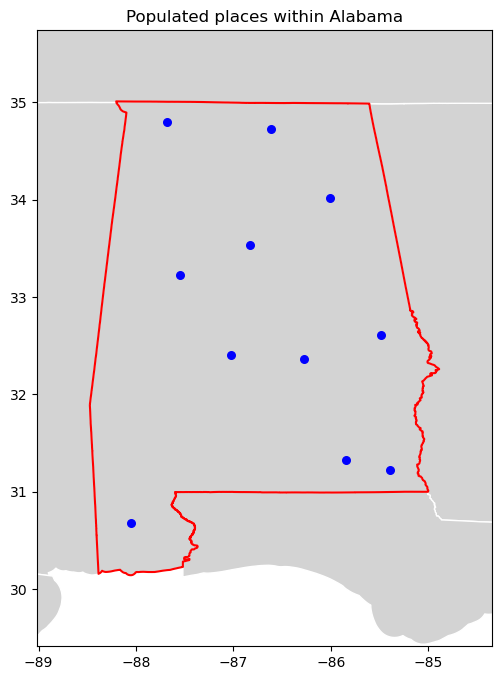

In [11]:
# Cell 3: Extract Alabama and find populated places within using the helper
from pathlib import Path
import geopandas as gpd
import matplotlib.pyplot as plt

# Ensure helper is defined (makes this cell self-contained)
def points_within_polygon(points_gdf, polygon_gdf):
    """Return points from `points_gdf` that fall within `polygon_gdf`.

    If CRSs differ, `polygon_gdf` is reprojected to `points_gdf`'s CRS.
    """
    if polygon_gdf.empty:
        return points_gdf.iloc[0:0].copy()

    if points_gdf.crs != polygon_gdf.crs:
        if points_gdf.crs is None or polygon_gdf.crs is None:
            raise ValueError('Both GeoDataFrames must have a CRS or share the same CRS.')
        polygon_gdf = polygon_gdf.to_crs(points_gdf.crs)

    # use union_all() to avoid deprecation warning if available
    if hasattr(polygon_gdf.geometry, 'union_all'):
        polygon_geom = polygon_gdf.geometry.union_all()
    else:
        polygon_geom = polygon_gdf.geometry.unary_union
    return points_gdf[points_gdf.within(polygon_geom)].copy()

states_dir = Path(r"C:\Users\mkeller\Downloads\tl_2025_us_state")
places_dir = Path(r"C:\Users\mkeller\Downloads\ne_10m_populated_places")

states_shp = next(states_dir.glob("*.shp"))
places_shp = next(places_dir.glob("*.shp"))

print('Reading populated places:', places_shp)
places = gpd.read_file(places_shp)
print('Reading states (again) for robustness:', states_shp)
states = gpd.read_file(states_shp)

print('States CRS:', states.crs, 'Places CRS:', places.crs)
if states.crs != places.crs:
    print('Reprojecting places to states CRS...')
    places = places.to_crs(states.crs)

# find a name-like column
name_col = None
for col in ("NAME", "name", "STATE_NAME", "STUSPS"):
    if col in states.columns:
        name_col = col
        break
if name_col is None:
    raise ValueError('No NAME-like column found in states file')

alabama = states[states[name_col].str.lower() == 'alabama']
if alabama.empty:
    raise ValueError('Alabama polygon not found')

# use the helper function defined above
alabama_places = points_within_polygon(places, alabama)
print(f'Found {len(alabama_places)} populated places in Alabama')

display(alabama_places.head())

# Plot Alabama and the points (zoomed to Alabama bounds)
fig, ax = plt.subplots(figsize=(8, 8))
states.plot(ax=ax, color='lightgray', edgecolor='white')
alabama.boundary.plot(ax=ax, edgecolor='red', linewidth=1.5)
if not alabama_places.empty:
    alabama_places.plot(ax=ax, color='blue', markersize=30)

# Zoom to Alabama bounds with a 15% margin
minx, miny, maxx, maxy = alabama.total_bounds
dx = (maxx - minx) * 0.15
dy = (maxy - miny) * 0.15
ax.set_xlim(minx - dx, maxx + dx)
ax.set_ylim(miny - dy, maxy + dy)
ax.set_aspect('equal')
ax.set_title('Populated places within Alabama')
plt.show()
